In [1]:
'''

Summary of the ISI histogram distribution values...


'''

'\n\nSummary of the ISI histogram distribution values...\n\n\n'

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pickle
from matplotlib.colors import ListedColormap

from functions import *

In [6]:
# import ISI histogram summaries

with open('synch_analysis_aut_testISI_E1.pickle', 'rb') as file:
    df_E1_aut = pickle.load(file)

print(df_E1_aut.head())

with open('synch_analysis_aut_testISI_E2.pickle', 'rb') as file:
    df_aut = pickle.load(file)

with open('synch_analysis_naut_testISI_E2.pickle', 'rb') as file:
    df_naut = pickle.load(file)


df_aut['I_inj'] = df_aut['I_inj'].round(0)
df_aut['w_e1_e2'] = df_aut['w_e1_e2'].round(0)
df_aut['w_e2_e1'] = df_aut['w_e2_e1'].round(0)

df_naut['I_inj'] = df_naut['I_inj'].round(0)
df_naut['w_e1_e2'] = df_naut['w_e1_e2'].round(0)
df_naut['w_e2_e1'] = df_naut['w_e2_e1'].round(0)


#Create a difference dataframe
diff_df = df_aut.copy()
diff_df['CV_isi'] = diff_df['CV_isi'] - df_naut['CV_isi']
diff_df['LV'] = diff_df['LV'] - df_naut['LV']

print(df_aut['I_inj'].unique())
print(df_naut['w_e1_e2'].unique())
print(df_aut['w_e2_e1'].unique())

''' NEED TO PICK THE FIXED VALUES '''
FIXED_VALUES = [64, 64, 204]

   neuron_number  I_inj  w_e1_e2     w_e2_e1  peak_isi        mean       std  \
0              6  120.0     20.0   73.333333    143.25  143.250000  0.000000   
1              7  120.0     20.0   82.222222    140.25  140.250000  0.000000   
2              8  120.0     20.0   91.111111    138.75  138.750000  0.000000   
3              9  120.0     20.0  100.000000     99.75   99.535714  0.958315   
4              9  120.0     20.0  100.000000    114.75  114.750000  0.000000   

   count_sum    CV_isi        LV  
0          1  0.000000  0.003995  
1          1  0.000000  0.018115  
2          1  0.000000  0.019261  
3          7  0.009628  0.066692  
4          3  0.000000  0.066692  
[120. 128. 137. 145. 154. 162. 171. 179. 187. 196. 204. 213. 221. 229.
 238. 246. 255. 263. 272. 280.]
[ 20.  29.  38.  47.  56.  64.  73.  82.  91. 100.]
[ 20.  29.  38.  47.  56.  64.  73.  82.  91. 100.]


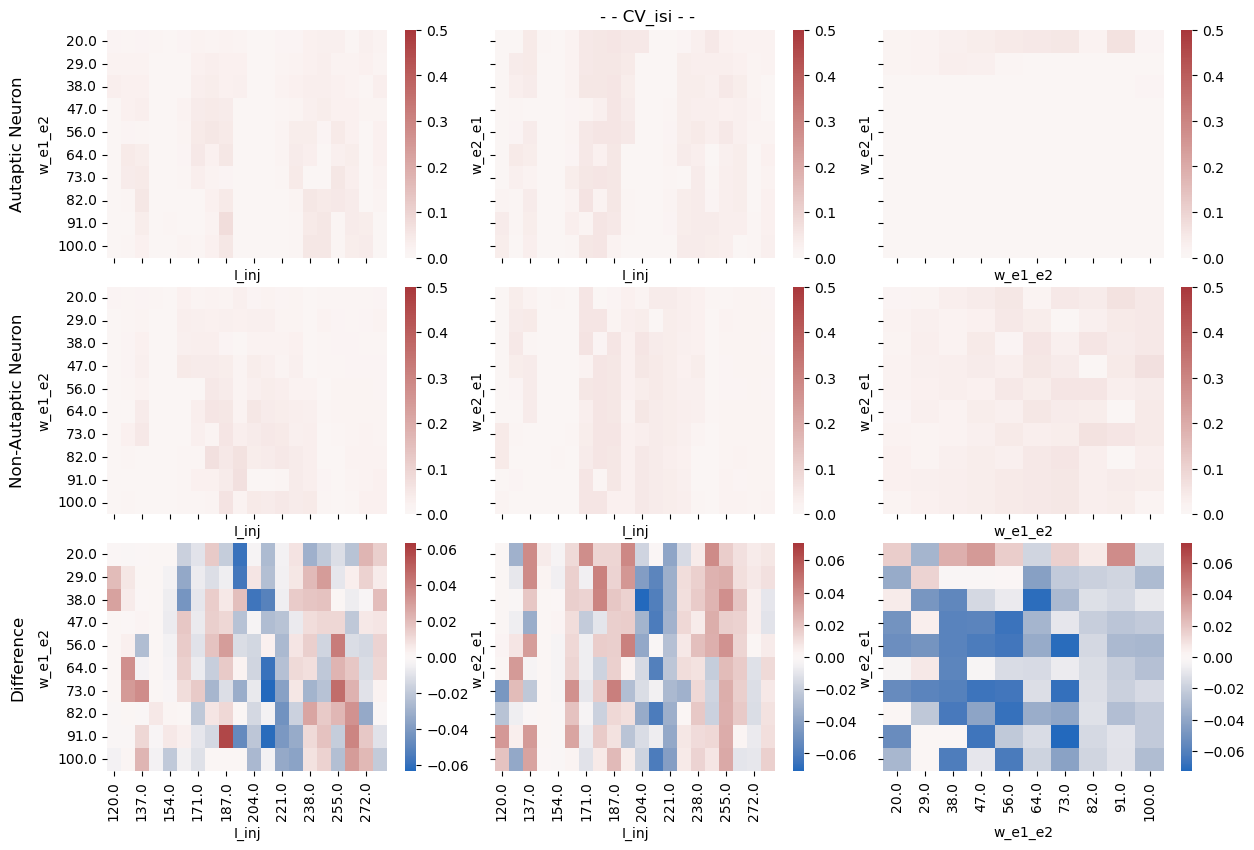

In [7]:
'''- - PLOT FT DISTANCE - -'''
# each row will be a different set of inputs
fig, ax = create_heatmaps(df_aut, df_naut, diff_df, metric = 'CV_isi', fixed_values = FIXED_VALUES, v_min = 0, v_max = 0.5)


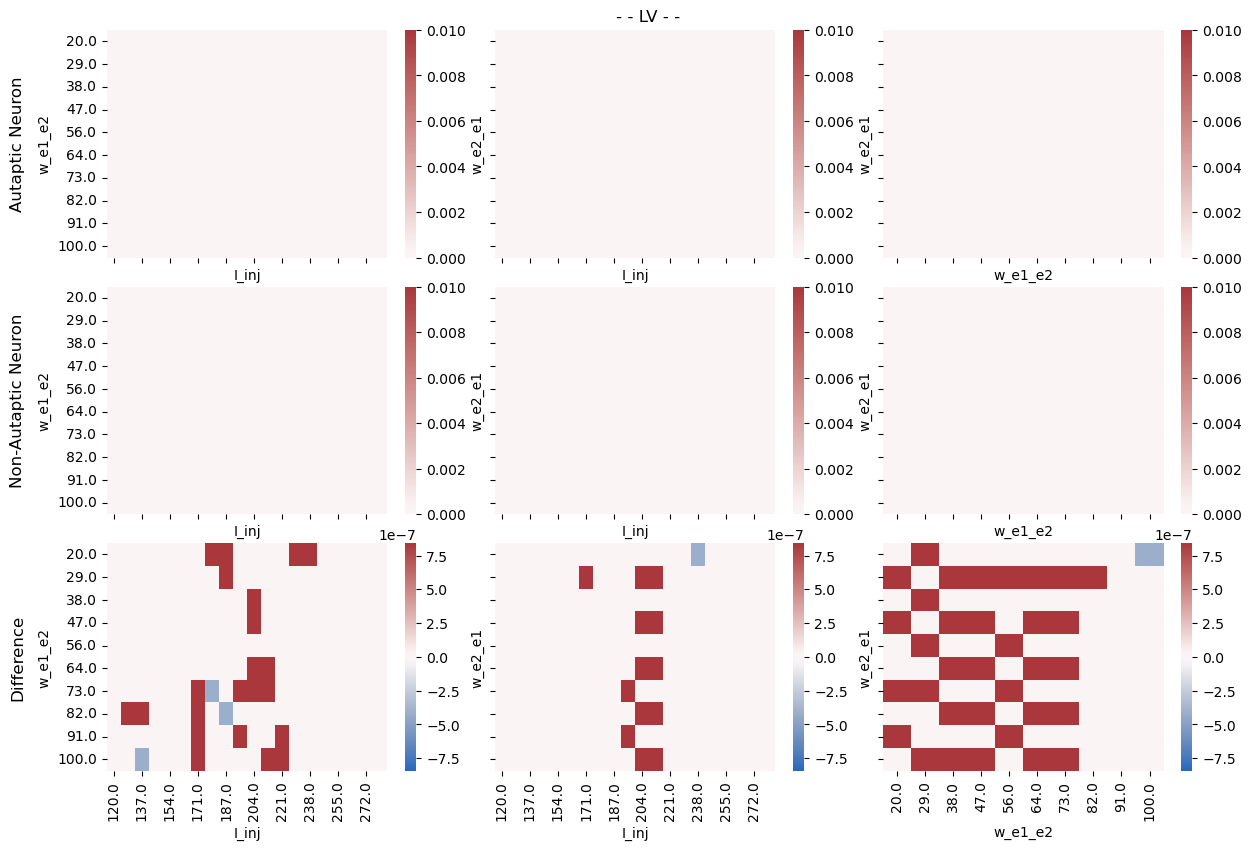

In [8]:
'''- - PLOT FT Earth mover's distance - -'''
# each row will be a different set of inputs
fig, ax = create_heatmaps(df_aut, df_naut, diff_df, metric = 'LV', fixed_values = FIXED_VALUES, v_min = 0, v_max = 0.01)
